In [337]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
import yfinance as yf
import scipy.stats as stats

In [832]:
df = pd.read_excel("../financial_data/vinfast_stock_data3.xlsx")

In [833]:
df

,Date,Open,High,Low,CloseClosing price adjusted for splits.,Adj CloseAdjusted closing price adjusted for splits and dividend and/or capital gain distributions.,Volume
0,2026-04-28 00:00:00,4.16,4.195,4.000,4.060,4.060,834600
1,2026-04-27 00:00:00,4.23,4.340,4.157,4.210,4.210,650700
2,2026-04-24 00:00:00,4.41,4.450,4.335,4.360,4.360,457200
3,2026-04-23 00:00:00,4.57,4.605,4.140,4.410,4.410,1333100
4,2026-04-22 00:00:00,4.88,5.120,4.580,4.690,4.690,1409000
...,...,...,...,...,...,...,...
1160,13 Sept 2021,9.71,9.710,9.710,9.710,9.710,400
1161,10 Sept 2021,9.69,9.690,9.680,9.680,9.680,700
1162,9 Sept 2021,9.61,9.691,9.610,9.682,9.682,400
1163,8 Sept 2021,9.71,9.710,9.710,9.710,9.710,3700


In [834]:
df.columns = ['date', 'open', 'high', 'low', 'close', 'adjusted_close', 'volume']

df['date'] = pd.to_datetime(df['date'], format='mixed')

In [835]:
df

,date,open,high,low,close,adjusted_close,volume
0,2026-04-28,4.16,4.195,4.000,4.060,4.060,834600
1,2026-04-27,4.23,4.340,4.157,4.210,4.210,650700
2,2026-04-24,4.41,4.450,4.335,4.360,4.360,457200
3,2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
4,2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
...,...,...,...,...,...,...,...
1160,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
1161,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
1162,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
1163,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700


In [836]:
df.isna().sum()

date              0
open              0
high              0
low               0
close             0
adjusted_close    0
volume            0
dtype: int64

In [837]:
df.duplicated().sum()

0

In [838]:
df['date'] = pd.to_datetime(df['date'], format="mixed")


In [839]:
df = df.sort_values(['date'],ascending=True) 
df


,date,open,high,low,close,adjusted_close,volume
1164,2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
1163,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
1162,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
1161,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
1160,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...,...
4,2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
3,2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
2,2026-04-24,4.41,4.450,4.335,4.360,4.360,457200
1,2026-04-27,4.23,4.340,4.157,4.210,4.210,650700


In [27]:
df.drop(['level_0', 'index'],axis=1,inplace=True) 
df

,date,open,high,low,adjusted_close_for_splits,adjusted_close_for_splits_dividend_capital_gain,volume
0,2021-09-07,9.93,9.980,9.7970,9.797,9.797,3700
1,2021-09-08,9.71,9.710,9.7100,9.710,9.710,3700
2,2021-09-09,9.61,9.691,9.6100,9.682,9.682,400
3,2021-09-10,9.69,9.690,9.6800,9.680,9.680,700
4,2021-09-13,9.71,9.710,9.7100,9.710,9.710,400
...,...,...,...,...,...,...,...
1159,2026-04-21,4.41,5.285,4.3750,4.760,4.760,5725900
1160,2026-04-22,4.88,5.120,4.5800,4.690,4.690,1409000
1161,2026-04-23,4.57,4.605,4.1400,4.410,4.410,1333100
1162,2026-04-24,4.41,4.450,4.3350,4.360,4.360,457200


In [840]:
df.corr(numeric_only=True)

,open,high,low,close,adjusted_close
open,1.000000,0.977757,0.981945,0.966715,0.966715
high,0.977757,1.000000,0.964280,0.985586,0.985586
low,0.981945,0.964280,1.000000,0.982141,0.982141
close,0.966715,0.985586,0.982141,1.000000,1.000000
adjusted_close,0.966715,0.985586,0.982141,1.000000,1.000000


In [841]:
plt.style.use("bmh")

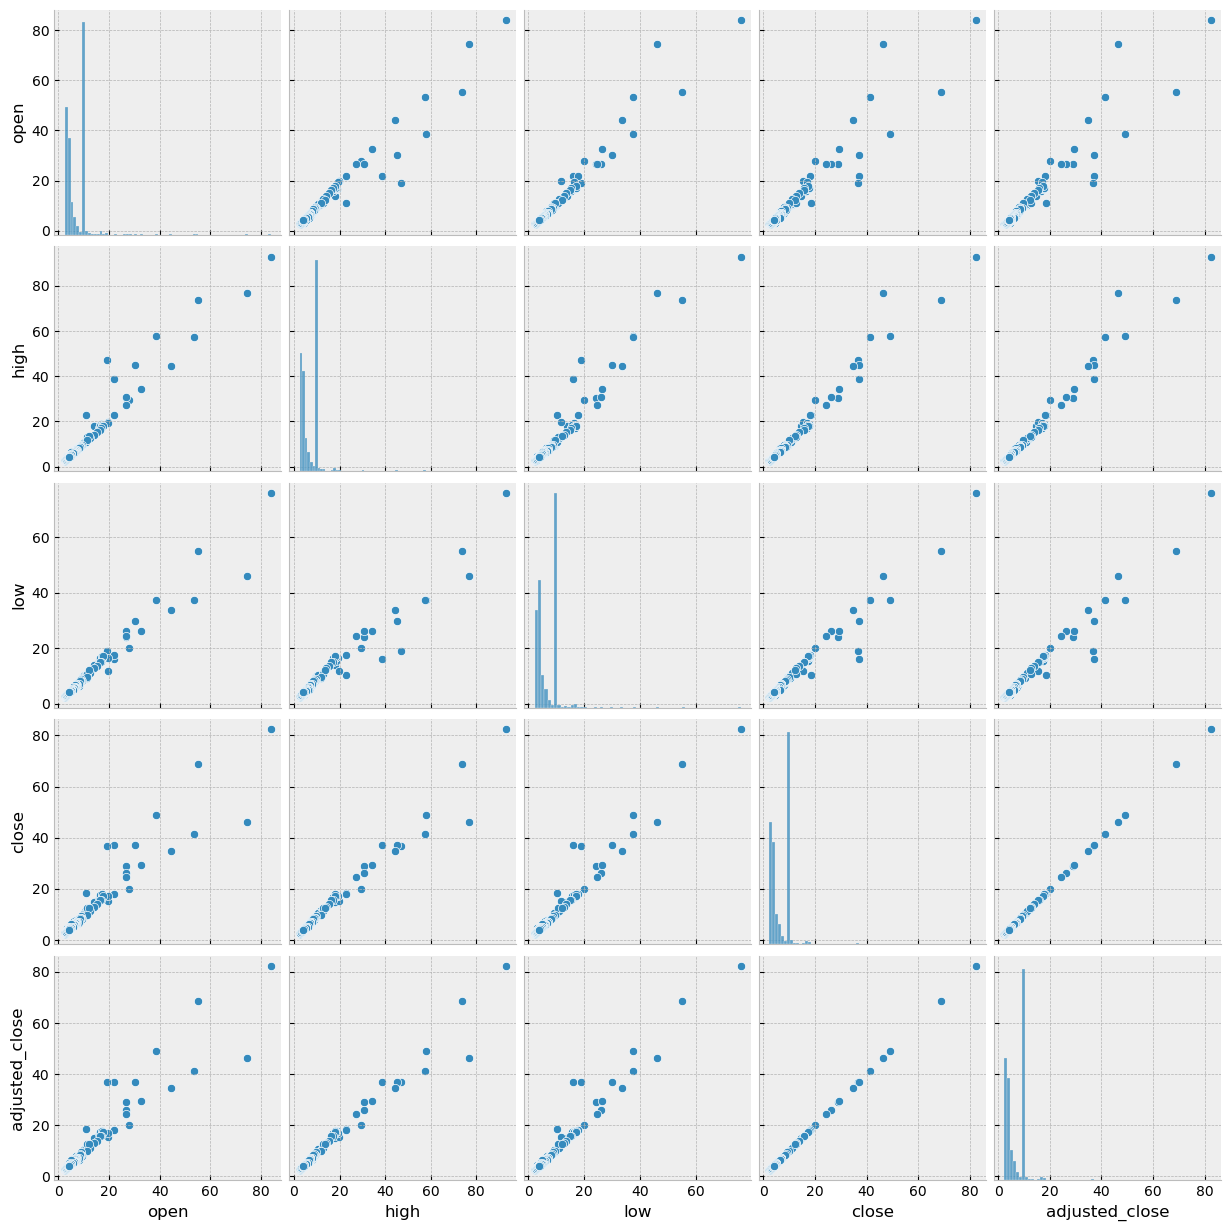

In [842]:
sns.pairplot(df)

In [843]:
df.index = df.date 
df.drop(['date'],axis=1,inplace=True) 


In [844]:
df

,open,high,low,close,adjusted_close,volume
date,,,,,,
2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2021-09-09,9.61,9.691,9.610,9.682,9.682,400
2021-09-10,9.69,9.690,9.680,9.680,9.680,700
2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...
2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
2026-04-24,4.41,4.450,4.335,4.360,4.360,457200


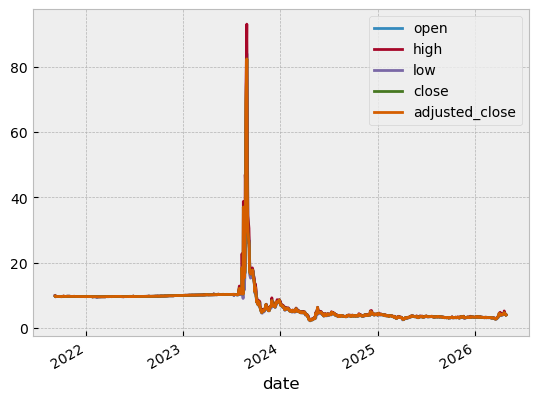

In [845]:
plt.Figure(figsize=(10,10))
df.plot(kind='line')

plt.show()

In [855]:
df.drop(['date'],axis=1,inplace=True)
df.head()

,open,high,low,close,adjusted_close,volume
date,,,,,,
2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2021-09-09,9.61,9.691,9.610,9.682,9.682,400
2021-09-10,9.69,9.690,9.680,9.680,9.680,700
2021-09-13,9.71,9.710,9.710,9.710,9.710,400


In [856]:
df.reset_index(inplace=True)

In [857]:
df

,date,open,high,low,close,adjusted_close,volume
0,2021-09-07,9.93,9.980,9.797,9.797,9.797,3700
1,2021-09-08,9.71,9.710,9.710,9.710,9.710,3700
2,2021-09-09,9.61,9.691,9.610,9.682,9.682,400
3,2021-09-10,9.69,9.690,9.680,9.680,9.680,700
4,2021-09-13,9.71,9.710,9.710,9.710,9.710,400
...,...,...,...,...,...,...,...
1160,2026-04-22,4.88,5.120,4.580,4.690,4.690,1409000
1161,2026-04-23,4.57,4.605,4.140,4.410,4.410,1333100
1162,2026-04-24,4.41,4.450,4.335,4.360,4.360,457200
1163,2026-04-27,4.23,4.340,4.157,4.210,4.210,650700


In [858]:
df = df.sort_values(['date'],ascending=True)

df = df[df.date > '2024-01-01']

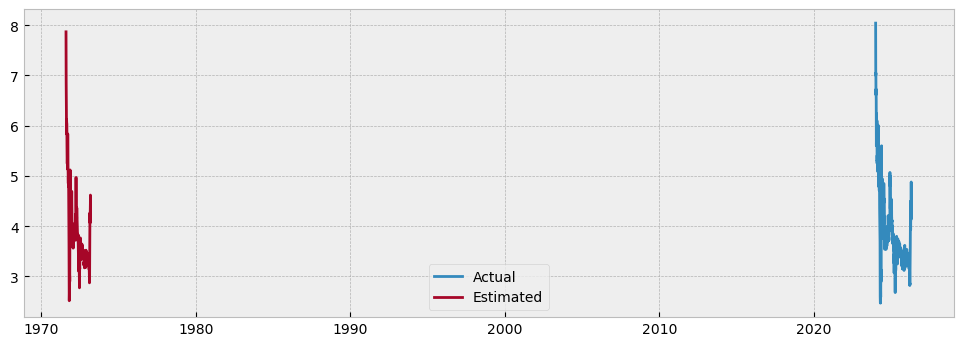

In [859]:
from statsmodels.tsa.seasonal import STL
open_price = pd.DataFrame(df[['open', 'date']])


stl = STL(open_price['open'], period=3) 
result = stl.fit()
seasonal, trend, resid = result.seasonal, result.trend, result.resid 


estimated = trend + seasonal 
plt.figure(figsize=(12,4)) 
plt.plot(open_price.date, open_price.open) 
plt.plot(estimated) 
plt.legend(['Actual', 'Estimated'])
plt.show()

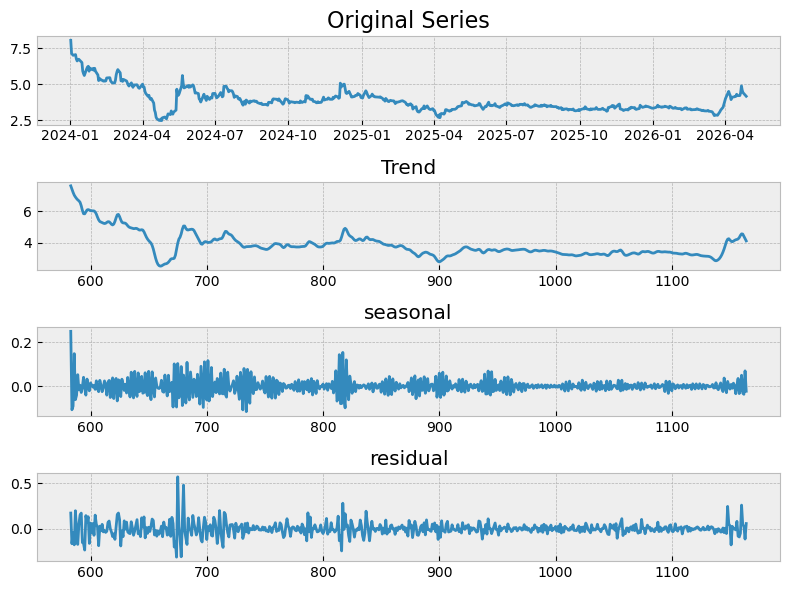

In [860]:
seasonal, trend, resid = result.seasonal, result.trend, result.resid 

plt.figure(figsize=(8,6)) 
plt.subplot(4,1,1) 
plt.plot(df.date, df['open']) 
plt.title("Original Series", fontsize=16) 

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend") 

plt.subplot(4,1,3) 
plt.plot(seasonal) 
plt.title("seasonal") 

plt.subplot(4,1,4) 
plt.plot(resid) 
plt.title("residual")
plt.tight_layout()

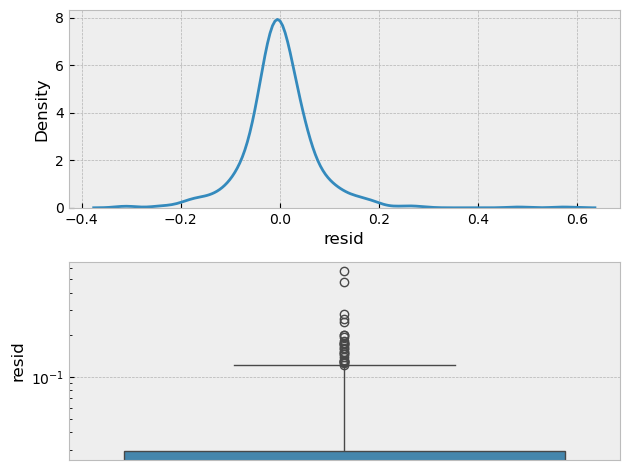

Shapiro -> ShapiroResult(statistic=0.8899385112825087, pvalue=5.828630661555075e-20)


In [861]:
fig, axes=plt.subplots(2) 

sns.kdeplot(resid, ax=axes[0])
sns.boxplot(resid, ax=axes[1])
axes[1].set_yscale("log") 
plt.tight_layout()
plt.show()

import scipy.stats as stats 


print (f"Shapiro -> {stats.shapiro(resid)}")

In [862]:
df

,date,open,high,low,close,adjusted_close,volume
583,2024-01-02,8.040,8.050,7.000,7.05,7.05,6666200
584,2024-01-03,7.135,7.210,6.835,7.08,7.08,4709600
585,2024-01-04,7.070,7.130,6.900,7.07,7.07,3466600
586,2024-01-05,7.000,7.060,6.900,7.02,7.02,1939900
587,2024-01-08,7.050,7.190,6.750,6.79,6.79,3767900
...,...,...,...,...,...,...,...
1160,2026-04-22,4.880,5.120,4.580,4.69,4.69,1409000
1161,2026-04-23,4.570,4.605,4.140,4.41,4.41,1333100
1162,2026-04-24,4.410,4.450,4.335,4.36,4.36,457200
1163,2026-04-27,4.230,4.340,4.157,4.21,4.21,650700


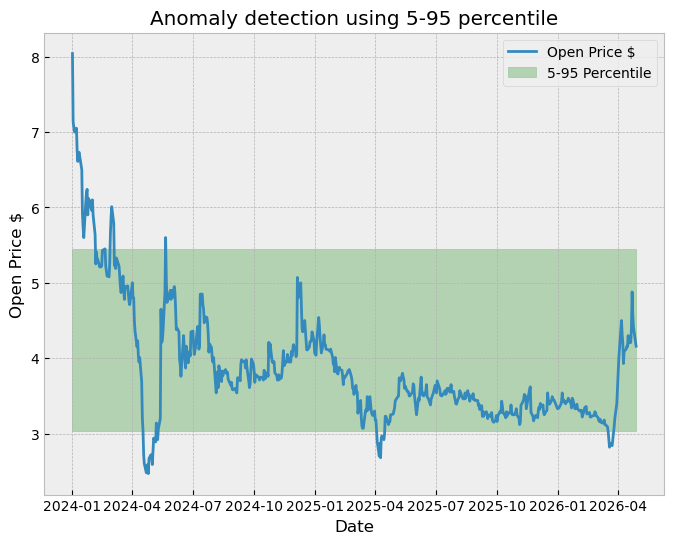

In [863]:
plt.figure(figsize=(8,6))
plt.plot(df.date, df.open) 

# plotting the median lines 

upper = np.percentile(df.open, 95) 
lower = np.percentile(df.open, 5) 

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=0.25) 
plt.title("Anomaly detection using 5-95 percentile") 
plt.ylabel("Open Price $") 
plt.xlabel("Date")

plt.legend(['Open Price $', '5-95 Percentile'])
plt.show()

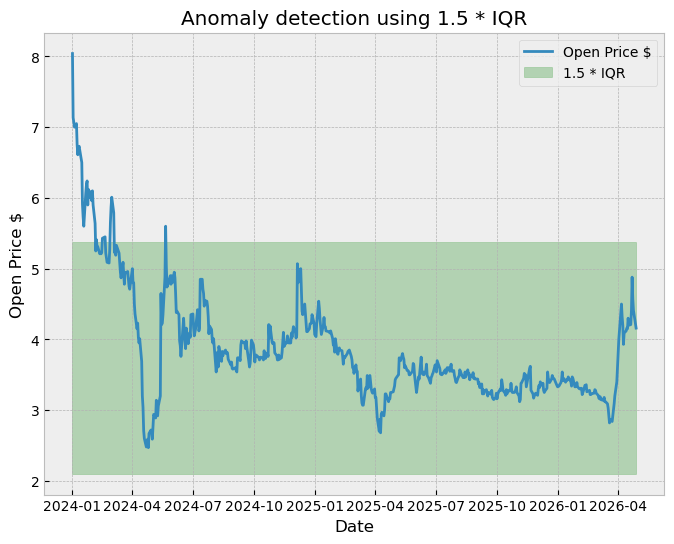

In [864]:
# using IQR

iqr = stats.iqr(df['open']) 




plt.figure(figsize=(8,6))
plt.plot(df.date, df.open) 

# plotting the median lines 

upper = (1.5 * iqr) + np.percentile(df.open, 75)
lower = np.percentile(df.open, 25) - (1.5 * iqr)

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', alpha=0.25) 
plt.title("Anomaly detection using 1.5 * IQR") 
plt.ylabel("Open Price $") 
plt.xlabel("Date")

plt.legend(['Open Price $', '1.5 * IQR'])
plt.show()

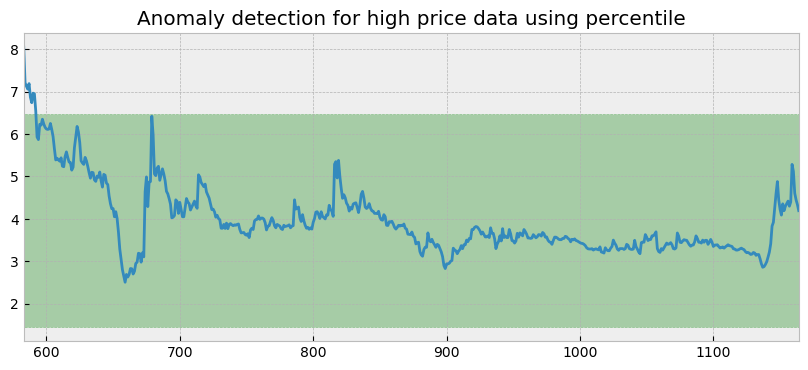

In [865]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['high'].mean() 
open_dev = df['high'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.high) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for high price data using percentile")
plt.show()

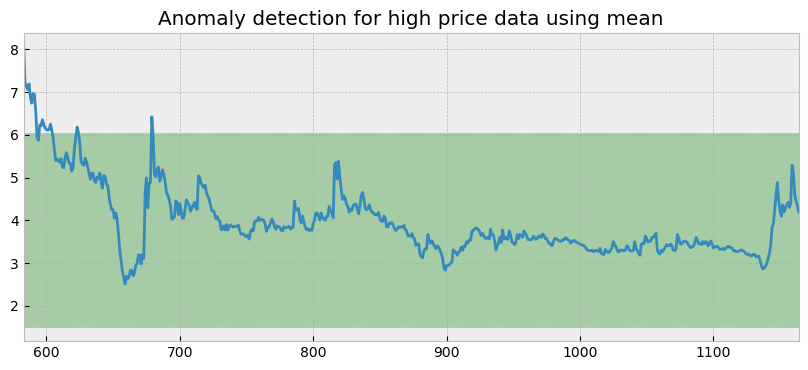

In [866]:
# checking if datapoints fit within 3 * std of mean
open_mu = df['low'].mean() 
open_dev = df['low'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(df.index, df.high) 
plt.fill_between([min(df.index), max(df.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(df.index), max(df.index))
plt.title("Anomaly detection for high price data using mean")
plt.show()

In [867]:
df.volume = df.volume.str.replace("-", "0")
df.volume = pd.to_numeric(df.volume)

AttributeError: Can only use .str accessor with string values!

In [868]:
df.iloc[5]

date              2024-01-09 00:00:00
open                             6.75
high                             6.87
low                              6.41
close                            6.65
adjusted_close                   6.65
volume                        3327700
Name: 588, dtype: object

In [895]:

print ("Creating day, month, year...")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['date'],ascending=True)

df['day'] = df['date'].dt.day 
df['month'] = df['date'].dt.month 
df['year'] = df['date'].dt.year

df = df.sort_values(['date'],ascending=True) 
print ("Splitting into X_train, X_test, Y_train, Y_test...")
X = df[['high','low', 'adjusted_close', 'volume', 'day', 'month', 'year']]
train_size=round(df.shape[0]*0.8)
test_size=round(df.shape[0]*0.2)
# replacing the anomalies
X_train = X.head(train_size)
 
X_test = X.tail(test_size)




def impute_median(column): 
    print (f"Computing for column: {column}")
    median = X_train[column].median() 
    print (f"median: {median}")
    std = X_train[column].std() 
    print (f"std: {std}")
    mean = X_train[column].mean() 
    print (f"mean: {mean}")
    # calculating the upper limit

    iqr = stats.iqr(df[column])


    upper = (1.5 * iqr) + np.percentile(X_train[column], 75)
    lower=np.percentile(X_train[column], 25) - (1.5 * iqr)
    print (f"upper: {upper}")
    print (f"lower: {lower}")
    # checking if the value is above or below 
    print ("Imputing...")

    values = [median if value > upper or value < lower else value for value in X_train[column]]
    print ("Done") 
    print ("----------------------")
    return values, median, upper, lower

print ("Imputing...")

# imputing mean for df['open']
iqr = stats.iqr(df['open']) 
upper = (1.5 * iqr) + np.percentile(df['open'], 75)
lower=np.percentile(df['open'], 25) - (1.5 * iqr)
median = df['open'].median()
df['open_imputed'] = [median if value > upper or value < lower else value for value in df['open']]




for column in X_train: 
    # this will impute X_train and X_test simultaneously
    print (f"column: {column}")

    X_train[f"{column}_imputed"], median, upper, lower = impute_median(column)
    
    X_test[f"{column}_imputed"] = [median if value > upper or value < lower else value for value in X_test[column]]
    print ("Done...")
    print ("------------------")




# -------------------------- CREATING THE LAGGING
y = df.open_imputed.values.reshape(-1,1)



Y_train = y[0:train_size]
Y_test = y[train_size:df.shape[0]]

X_train = X_train.drop(['day_imputed', 'month_imputed', 'year_imputed'],axis=1)
X_test = X_test.drop(['day_imputed', 'month_imputed', 'year_imputed'],axis=1)


Creating day, month, year...
Splitting into X_train, X_test, Y_train, Y_test...
Imputing...
column: high
Computing for column: high
median: 3.83
std: 0.8777066884512452
mean: 4.066912017167382
upper: 5.6602500000000004
lower: 2.1887499999999998
Imputing...
Done
----------------------
Done...
------------------
column: low
Computing for column: low
median: 3.6875
std: 0.7992202161378477
mean: 3.8586030042918456
upper: 5.203500000000001
lower: 2.241249999999999
Imputing...
Done
----------------------
Done...
------------------
column: adjusted_close
Computing for column: adjusted_close
median: 3.75
std: 0.8330754018429259
mean: 3.959388412017167
upper: 5.42375
lower: 2.2337500000000006
Imputing...
Done
----------------------
Done...
------------------
column: volume
Computing for column: volume
median: 734450.0
std: 1371466.8761462246
mean: 1186409.2274678112
upper: 2605500.0
lower: -723550.0
Imputing...
Done
----------------------
Done...
------------------
column: day
Computing for col

/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_63762/1599605086.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[f"{column}_imputed"], median, upper, lower = impute_median(column)
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_63762/1599605086.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[f"{column}_imputed"] = [median if value > upper or value < lower else value for value in X_test[column]]
/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_63762/15

In [896]:
print (np.shape(Y_train)) 
print (np.shape(Y_test))

(466, 1)
(116, 1)


In [897]:
print (np.shape(X_train)) 
print (np.shape(X_test))

(466, 11)
(116, 11)


In [898]:
X_test

,high,low,adjusted_close,volume,day,month,year,high_imputed,low_imputed,adjusted_close_imputed,volume_imputed
1049,3.630,3.420,3.530,780000,10,11,2025,3.630,3.420,3.530,780000.0
1050,3.570,3.460,3.485,277200,11,11,2025,3.570,3.460,3.485,277200.0
1051,3.490,3.400,3.470,474600,12,11,2025,3.490,3.400,3.470,474600.0
1052,3.510,3.330,3.360,338500,13,11,2025,3.510,3.330,3.360,338500.0
1053,3.515,3.330,3.460,367200,14,11,2025,3.515,3.330,3.460,367200.0
...,...,...,...,...,...,...,...,...,...,...,...
1160,5.120,4.580,4.690,1409000,22,4,2026,5.120,4.580,4.690,1409000.0
1161,4.605,4.140,4.410,1333100,23,4,2026,4.605,4.140,4.410,1333100.0
1162,4.450,4.335,4.360,457200,24,4,2026,4.450,4.335,4.360,457200.0
1163,4.340,4.157,4.210,650700,27,4,2026,4.340,4.157,4.210,650700.0


In [899]:
df.shape

(582, 11)

In [900]:
lagged_volume = X_train['volume_imputed'].values
lagged_volume = np.insert(lagged_volume, 0, 0)
lagged_volume = lagged_volume[:-1]

X_train['lagged_volume'] = lagged_volume 

# lagged adjusted close



lagged_adjusted_close = X_train['adjusted_close_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
X_train['lagged_adjusted_close'] = lagged_adjusted_close



# lagged adjusted high
lagged_high = X_train['high_imputed'].values 
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
X_train['lagged_high'] = lagged_high 

# lagged low 
lagged_low = X_train['low_imputed'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
X_train['lagged_low'] = lagged_low 

X_train.head()
# ----------------------------

lagged_volume = X_test['volume_imputed'].values
lagged_volume = np.insert(lagged_volume, 0, 0)
lagged_volume = lagged_volume[:-1]

X_test['lagged_volume'] = lagged_volume 

# lagged adjusted close


lagged_adjusted_close = X_test['adjusted_close_imputed'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
X_test['lagged_adjusted_close'] = lagged_adjusted_close



# lagged adjusted high
lagged_high = X_test['high_imputed'].values 
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
X_test['lagged_high'] = lagged_high 

# lagged low 
lagged_low = X_test['low_imputed'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
X_test['lagged_low'] = lagged_low 







In [901]:
X_train.head()

,high,low,adjusted_close,volume,day,month,year,high_imputed,low_imputed,adjusted_close_imputed,volume_imputed,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
583,8.05,7.000,7.05,6666200,2,1,2024,3.83,3.6875,3.75,734450.0,0.0,0.00,0.00,0.0000
584,7.21,6.835,7.08,4709600,3,1,2024,3.83,3.6875,3.75,734450.0,734450.0,3.75,3.83,3.6875
585,7.13,6.900,7.07,3466600,4,1,2024,3.83,3.6875,3.75,734450.0,734450.0,3.75,3.83,3.6875
586,7.06,6.900,7.02,1939900,5,1,2024,3.83,3.6875,3.75,1939900.0,734450.0,3.75,3.83,3.6875
587,7.19,6.750,6.79,3767900,8,1,2024,3.83,3.6875,3.75,734450.0,1939900.0,3.75,3.83,3.6875


In [902]:
X_test

,high,low,adjusted_close,volume,day,month,year,high_imputed,low_imputed,adjusted_close_imputed,volume_imputed,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
1049,3.630,3.420,3.530,780000,10,11,2025,3.630,3.420,3.530,780000.0,0.0,0.000,0.000,0.000
1050,3.570,3.460,3.485,277200,11,11,2025,3.570,3.460,3.485,277200.0,780000.0,3.530,3.630,3.420
1051,3.490,3.400,3.470,474600,12,11,2025,3.490,3.400,3.470,474600.0,277200.0,3.485,3.570,3.460
1052,3.510,3.330,3.360,338500,13,11,2025,3.510,3.330,3.360,338500.0,474600.0,3.470,3.490,3.400
1053,3.515,3.330,3.460,367200,14,11,2025,3.515,3.330,3.460,367200.0,338500.0,3.360,3.510,3.330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160,5.120,4.580,4.690,1409000,22,4,2026,5.120,4.580,4.690,1409000.0,734450.0,4.760,5.285,4.375
1161,4.605,4.140,4.410,1333100,23,4,2026,4.605,4.140,4.410,1333100.0,1409000.0,4.690,5.120,4.580
1162,4.450,4.335,4.360,457200,24,4,2026,4.450,4.335,4.360,457200.0,1333100.0,4.410,4.605,4.140
1163,4.340,4.157,4.210,650700,27,4,2026,4.340,4.157,4.210,650700.0,457200.0,4.360,4.450,4.335


In [903]:
X_train = X_train[['day', 'month', 'year', 'lagged_volume', 'lagged_adjusted_close', 'lagged_high', 'lagged_low']].iloc[1:]
X_test = X_test[['day', 'month', 'year', 'lagged_volume', 'lagged_adjusted_close', 'lagged_high', 'lagged_low']].iloc[1:]

Y_train = Y_train[1:]
Y_test = Y_test[1:]


X_train.head()

,day,month,year,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
584,3,1,2024,734450.0,3.75,3.83,3.6875
585,4,1,2024,734450.0,3.75,3.83,3.6875
586,5,1,2024,734450.0,3.75,3.83,3.6875
587,8,1,2024,1939900.0,3.75,3.83,3.6875
588,9,1,2024,734450.0,3.75,3.83,3.6875


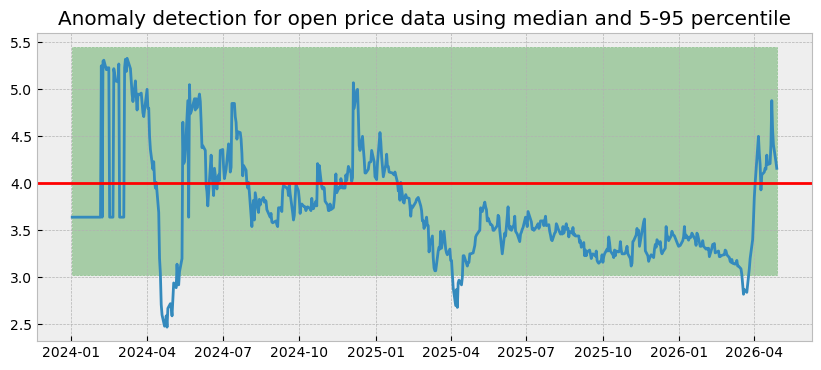

In [904]:


lower=np.percentile(df.open, 5)
upper = np.percentile(df.open, 95) 
plt.figure(figsize=(10,4)) 
plt.plot(df.date, df.open_imputed) 
plt.fill_between([min(df.date), max(df.date)], lower, upper, color='g', alpha=0.3, linestyle='--')


plt.axhline(y=4, color='r')
plt.title("Anomaly detection for open price data using median and 5-95 percentile")
plt.show()

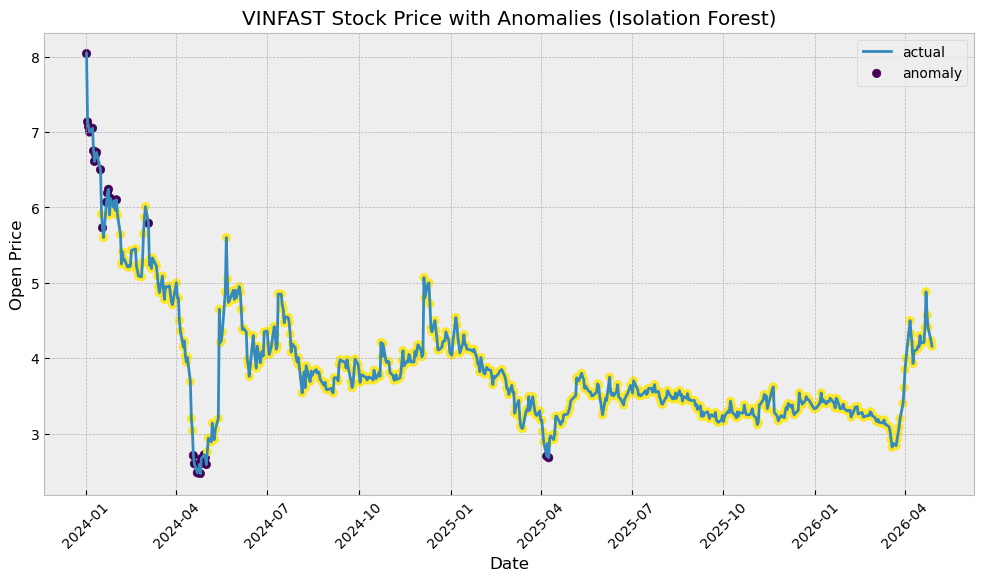

In [905]:
from sklearn.ensemble import IsolationForest

# Prepare the data for Isolation Forest
X = df['open'].values.reshape(-1, 1)

# Train the Isolation Forest model
model = IsolationForest(contamination=0.05)
model.fit(X)

# Predict the anomalies
anomalies = model.predict(X)

# Plot the anomalies
plt.figure(figsize=(12, 6))
plt.plot(df.date, df['open'])
plt.scatter(df.date, df['open'], c=anomalies, label='Anomaly')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.title('VINFAST Stock Price with Anomalies (Isolation Forest)')
plt.xticks(rotation=45)
plt.legend(['actual', 'anomaly'])
plt.grid(True)

plt.show()

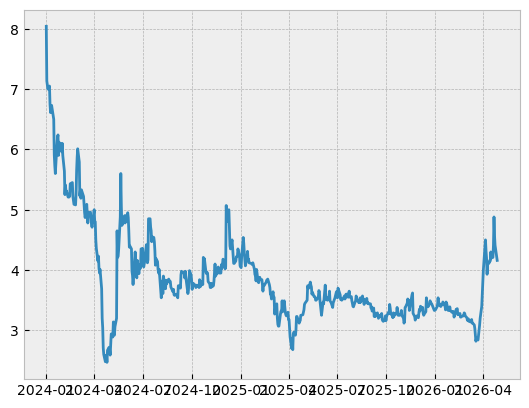

In [906]:
plt.plot(df.date, df.open)

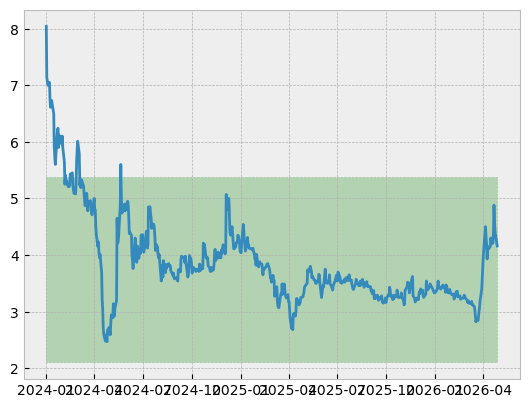

In [907]:
iqr = stats.iqr(df['open']) 

upper = (1.5*iqr) + np.percentile(df['open'], 75)
lower = np.percentile(df['open'], 25) - (1.5*iqr) 

plt.plot(df.date, df.open) 

plt.fill_between([df.date.min(), df.date.max()], lower, upper, color='g', linestyle='--', alpha=0.25)

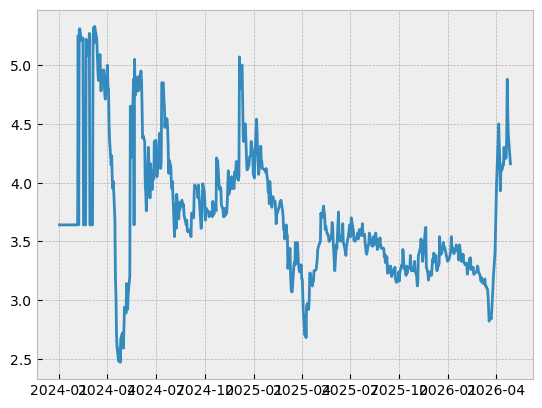

In [908]:
iqr = stats.iqr(df['open']) 

upper = (1.5*iqr) + np.percentile(df['open'], 75)
lower = np.percentile(df['open'], 25) - (1.5*iqr) 

plt.plot(df.date, df.open_imputed) 



In [909]:
df.open_imputed

583     3.64
584     3.64
585     3.64
586     3.64
587     3.64
        ... 
1160    4.88
1161    4.57
1162    4.41
1163    4.23
1164    4.16
Name: open_imputed, Length: 582, dtype: float64

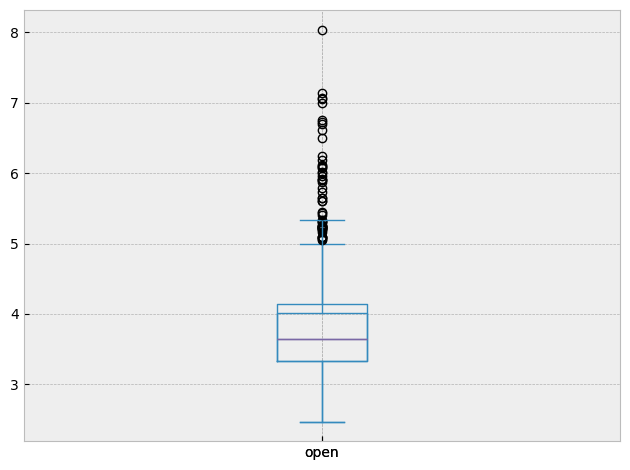

In [910]:
df['open_imputed'].plot(kind='box')
df['open'].plot(kind='box')
plt.tight_layout()

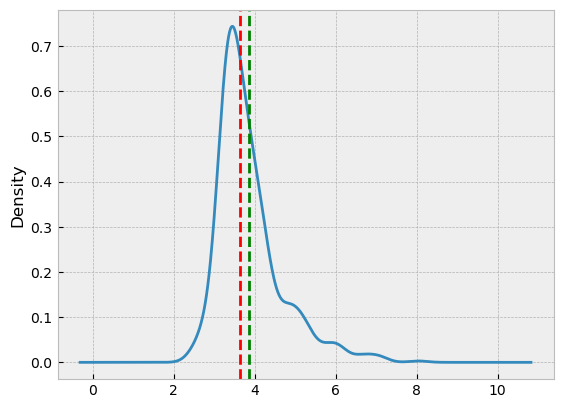

In [911]:

plt.ylabel("Open Price $")

df['open'].plot(kind='kde')
plt.axvline(x=df['open'].median(), color='r', linestyle='--')
plt.axvline(x=df['open'].mean(), color='g', linestyle='--')
plt.show()

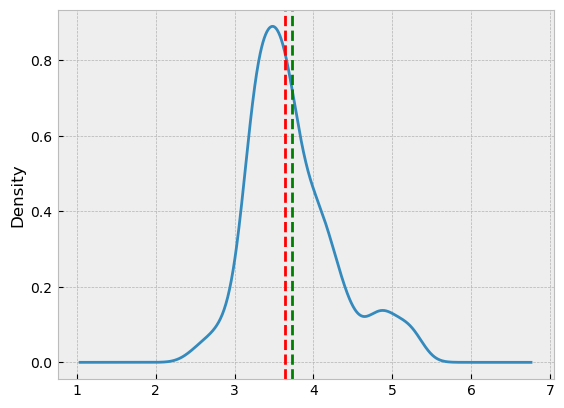

In [912]:

plt.ylabel("Open Price $ imputed")

df['open_imputed'].plot(kind='kde')
plt.axvline(x=df['open_imputed'].median(), color='r', linestyle='--')
plt.axvline(x=df['open_imputed'].mean(), color='g', linestyle='--')
plt.show()

# Building the model

In [913]:
from sklearn.model_selection import train_test_split, GridSearchCV 
from xgboost import XGBRegressor


In [914]:
print (np.shape(X_train)) 
print (np.shape(Y_train)) 
print ("---")
print (np.shape(X_test)) 
print (np.shape(Y_test))

(465, 7)
(465, 1)
---
(115, 7)
(115, 1)


In [915]:
X_train.head()

,day,month,year,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
584,3,1,2024,734450.0,3.75,3.83,3.6875
585,4,1,2024,734450.0,3.75,3.83,3.6875
586,5,1,2024,734450.0,3.75,3.83,3.6875
587,8,1,2024,1939900.0,3.75,3.83,3.6875
588,9,1,2024,734450.0,3.75,3.83,3.6875


In [916]:
model = XGBRegressor() 

model.fit(X_train, Y_train)
pred = model.predict(X_test)

In [917]:
# metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [918]:
np.shape(Y_test)

(115, 1)

In [919]:
np.shape(X_test)

(115, 7)

In [920]:
print (root_mean_squared_error(y_pred=pred, y_true=Y_test))
print (mean_absolute_error(y_pred=pred, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=pred))

0.056684510429404
0.04223171132958454
0.9790685183278346


In [921]:
Y_test

array([[3.52 ],
       [3.46 ],
       [3.5  ],
       [3.33 ],
       [3.49 ],
       [3.54 ],
       [3.59 ],
       [3.62 ],
       [3.282],
       [3.23 ],
       [3.17 ],
       [3.2  ],
       [3.24 ],
       [3.21 ],
       [3.3  ],
       [3.35 ],
       [3.32 ],
       [3.4  ],
       [3.35 ],
       [3.38 ],
       [3.28 ],
       [3.25 ],
       [3.27 ],
       [3.31 ],
       [3.54 ],
       [3.45 ],
       [3.43 ],
       [3.39 ],
       [3.44 ],
       [3.49 ],
       [3.46 ],
       [3.44 ],
       [3.37 ],
       [3.35 ],
       [3.33 ],
       [3.34 ],
       [3.39 ],
       [3.43 ],
       [3.54 ],
       [3.42 ],
       [3.45 ],
       [3.395],
       [3.43 ],
       [3.42 ],
       [3.43 ],
       [3.47 ],
       [3.4  ],
       [3.34 ],
       [3.47 ],
       [3.45 ],
       [3.33 ],
       [3.33 ],
       [3.34 ],
       [3.39 ],
       [3.33 ],
       [3.3  ],
       [3.31 ],
       [3.3  ],
       [3.31 ],
       [3.22 ],
       [3.31 ],
       [3.35 ],
       [

In [922]:
df.tail(test_size).date

1049   2025-11-10
1050   2025-11-11
1051   2025-11-12
1052   2025-11-13
1053   2025-11-14
          ...    
1160   2026-04-22
1161   2026-04-23
1162   2026-04-24
1163   2026-04-27
1164   2026-04-28
Name: date, Length: 116, dtype: datetime64[ns]

In [923]:
np.shape(pred)

(115,)

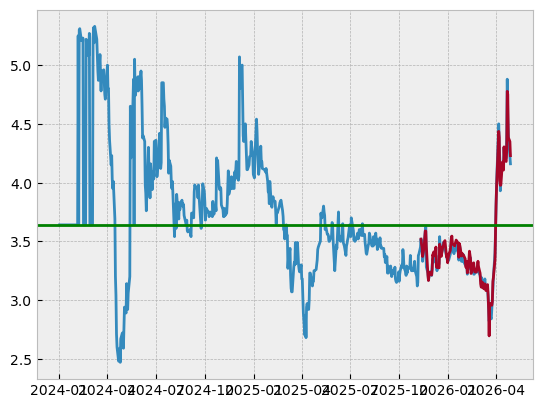

In [924]:
# plotting


plt.plot(df.date, df.open_imputed)
plt.plot(df.tail(test_size).date.iloc[1:], pred)

plt.axhline(y=df['open'].median(), color='g')

Text(0.5, 1.0, 'Zoomed in VINFAST opening prices prediction. R2 = 0.979')

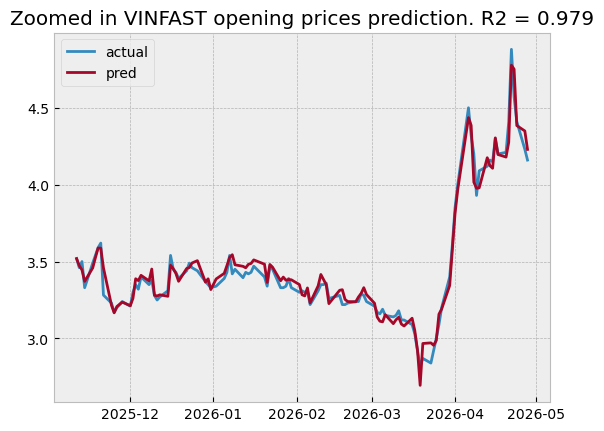

In [925]:
plt.plot(df.tail(test_size).date.iloc[1:], Y_test)
plt.plot(df.tail(test_size).date.iloc[1:], pred)

plt.legend(['actual', 'pred'])

plt.title(f"Zoomed in VINFAST opening prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")

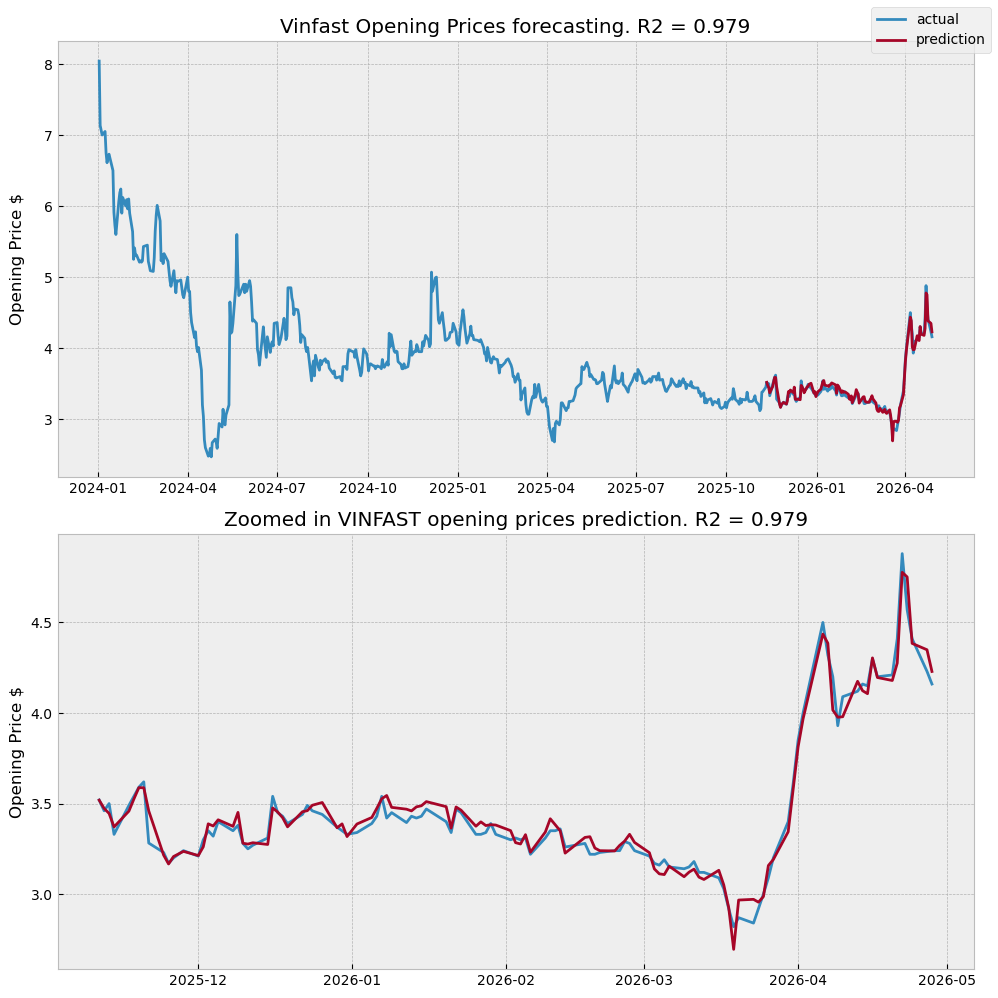

In [926]:
# plotting

fig, axes=plt.subplots(2, figsize=(10,10))




axes[0].plot(df.date, df.open)
axes[0].plot(df.tail(test_size).date.iloc[1:], pred)



axes[0].set_title(f"Vinfast Opening Prices forecasting. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")
axes[0].set_ylabel("Opening Price $")

# ---------

axes[1].plot(df.tail(test_size).date.iloc[1:], Y_test)
axes[1].plot(df.tail(test_size).date.iloc[1:], pred)



axes[1].set_title(f"Zoomed in VINFAST opening prices prediction. R2 = {np.round(r2_score(y_true=Y_test, y_pred=pred), 3)}")
axes[1].set_ylabel("Opening Price $")
fig.legend(['actual', 'prediction'])

fig.align_ylabels()

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Y test')

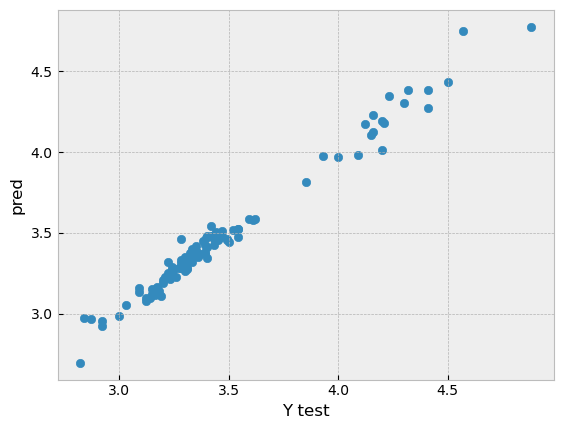

In [927]:
plt.scatter(Y_test, pred) 
plt.ylabel("pred") 
plt.xlabel("Y test")

In [928]:
X_train.shape

(465, 7)

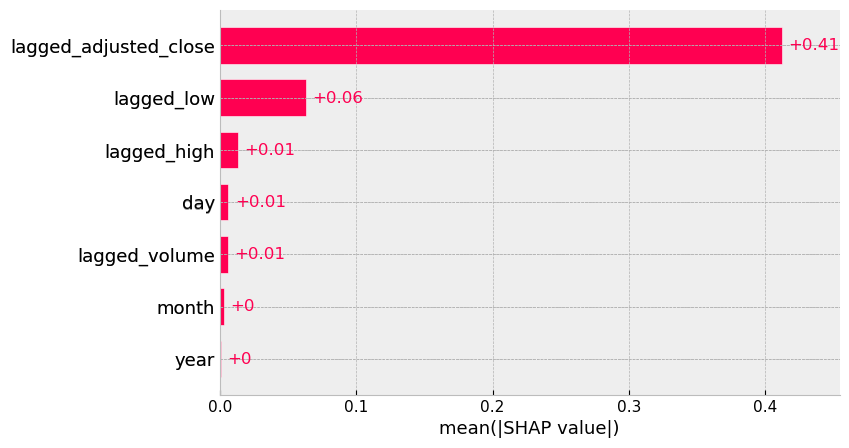

In [930]:
import shap 


explainer = shap.TreeExplainer(model) 
shap_values = explainer(X_test) 


shap.plots.bar(shap_values)

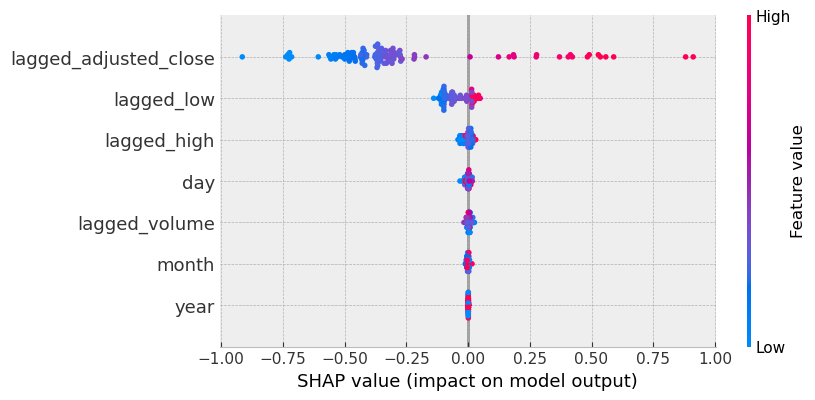

In [931]:
shap.plots.beeswarm(shap_values)

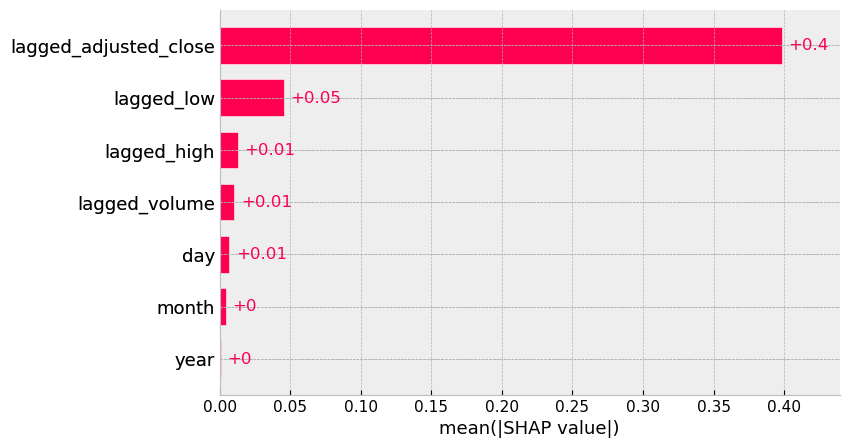

In [932]:



train_shap_values = explainer(X_train) 


shap.plots.bar(train_shap_values)

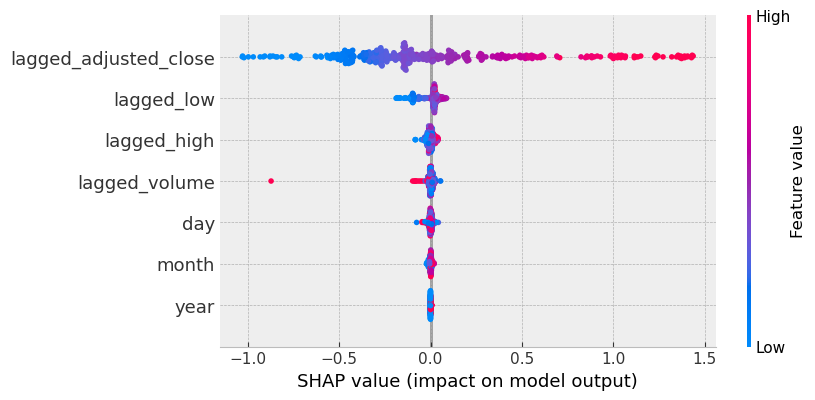

In [933]:



train_shap_values = explainer(X_train) 


shap.plots.beeswarm(train_shap_values)

In [935]:
X_test.head()

,day,month,year,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
1050,11,11,2025,780000.0,3.530,3.630,3.42
1051,12,11,2025,277200.0,3.485,3.570,3.46
1052,13,11,2025,474600.0,3.470,3.490,3.40
1053,14,11,2025,338500.0,3.360,3.510,3.33
1054,17,11,2025,367200.0,3.460,3.515,3.33


In [936]:
# test prediction 

test_data = pd.DataFrame({

    'day': [29],
    'month': [4],
    'year': [2026],
    'lagged_volume': [834600],
    'lagged_adjusted_close': [4.06],
    'lagged_high': [4.1950],
    'lagged_low': [4],
    



})

model.predict(test_data)



array([4.0493603], dtype=float32)

In [937]:
mae = mean_absolute_error(y_pred=pred, y_true=Y_test)


In [938]:
upper = 4.0493603 + mae
lower = 4.0493603 - mae 


print (f"Upper -> {upper}")
print (f"lower -> {lower}")

Upper -> 4.091592011329585
lower -> 4.007128588670415


In [822]:
X_test

,day,month,year,lagged_volume,lagged_adjusted_close_for_splits_dividend_capital_gain,lagged_high,lagged_low
466,10,11,2025,417500.0,3.400,3.450,3.321
467,11,11,2025,780000.0,3.430,3.630,3.420
468,12,11,2025,277200.0,3.530,3.570,3.460
469,13,11,2025,474600.0,3.485,3.490,3.400
470,14,11,2025,338500.0,3.470,3.510,3.330
...,...,...,...,...,...,...,...
576,21,4,2026,801300.0,4.210,4.400,4.190
577,22,4,2026,736800.0,4.350,5.285,4.375
578,23,4,2026,1409000.0,4.760,5.120,4.580
579,24,4,2026,1333100.0,4.690,4.605,4.140


In [ ]:
np.mean(df['lagged_adjusted_close_for_splits_dividend_capital_gain', df['lagged'])

In [733]:
import joblib 

joblib.dump(model, "../models/time_series/vinfast_forecaster.pkl")

['../models/time_series/vinfast_forecaster.pkl']

In [764]:
print (4.054488+ 0.0555836671580439)
print (4.054488 - 0.0555836671580439)

4.110071667158044
3.9989043328419562


In [753]:
# testing arima

from pmdarima.arima import auto_arima

df = df.sort_values(['date'],ascending=True)
X_arima = df[['date', 'open_imputed']]
X_arima.index = pd.to_datetime(X_arima.date)
X_arima.drop(['date'],axis=1,inplace=True) 
X_train_arima = X_arima.head(train_size)
X_test_arima = X_arima.tail(test_size)

arima = auto_arima(y=X_train_arima) 


pred = arima.predict(n_periods=X_test_arima.shape[0]) 



/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_63762/3651420301.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_arima.drop(['date'],axis=1,inplace=True)
/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [754]:
X_test_arima

,open_imputed
date,
2025-11-07,3.39
2025-11-10,3.45
2025-11-11,3.52
2025-11-12,3.46
2025-11-13,3.50
...,...
2026-04-21,4.41
2026-04-22,4.88
2026-04-23,4.57


In [755]:
pred

465    3.308031
466    3.308031
467    3.308031
468    3.308031
469    3.308031
         ...   
576    3.308031
577    3.308031
578    3.308031
579    3.308031
580    3.308031
Length: 116, dtype: float64

In [756]:
train_pred = arima.predict(n_periods=len(X_train_arima))

/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


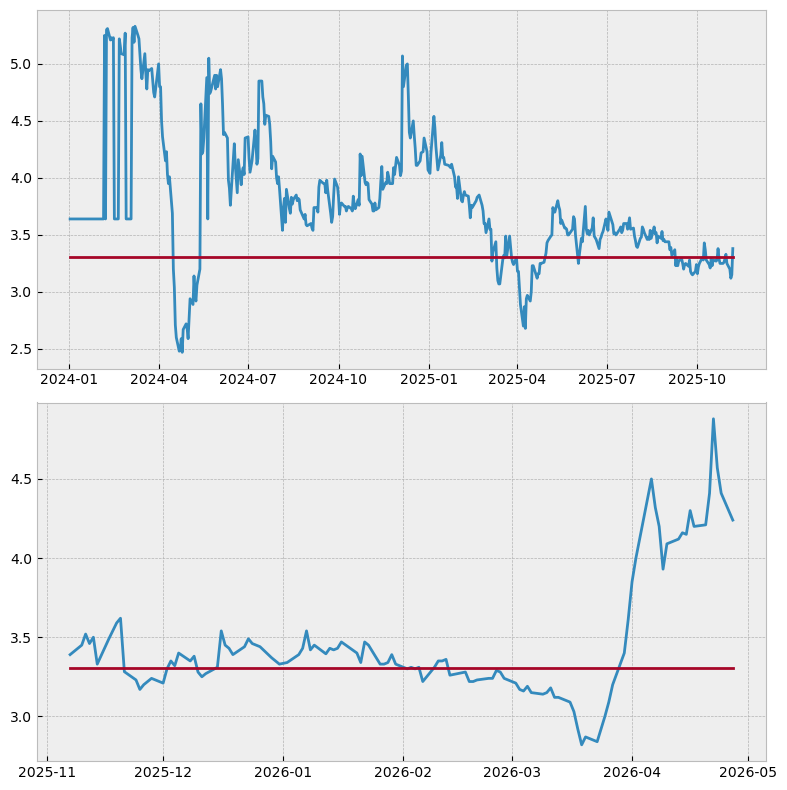

In [757]:
fig, axes = plt.subplots(2, figsize=(8,8))

axes[0].plot(X_train_arima.index, df.open_imputed.head(train_size))

# plotting arima

axes[0].plot(X_train_arima.index, train_pred)


axes[1].plot(X_test_arima.index, df.open_imputed.tail(test_size))
axes[1].plot(X_test_arima.index, pred)

plt.tight_layout()